# Detekcija laznih oglasa za posao

Prakticni deo seminarskog rada demonstrira kako kvalitet i predobrada tekstualnih podataka uticu na modele za klasifikaciju teksta. Primer je binarna klasifikacija oglasa za posao na klase `real` i `fake`.

## 1. Plan

U ovom notebook-u proveravamo sledece:

- kvalitet teksta: duzina dokumenata, vocabulary size, lexical diversity i sum
- predobrada: tokenizacija, Unicode/case normalizacija, HTML ciscenje, stop-reci, stemming, lematizacija i augmentation
- reprezentacija: Bag of Words, TF-IDF, karakter n-grami kao subword pristup i dense LSA baseline
- modeli: Logistic Regression i Multinomial Naive Bayes
- evaluacija: train/test split, cross-validation, precision, recall, F1, konfuziona matrica i analiza gresaka


In [21]:
import importlib.util
import random
import re
import string
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
from scipy.sparse import hstack

from nltk.stem import PorterStemmer

from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")


## 2. Ucitavanje skupa podataka

Koristi se lokalni skup oglasa za posao sa tekstualnim kolonama i binarnom ciljnom promenljivom `is_fake`. Fokus modela je na tekstu oglasa, dok se neke dodatne kolone koriste samo za analizu kvaliteta i potencijalnih shortcut signala.


In [22]:
DATASET_PATH = "fake_real_job_postings.csv"

df = pd.read_csv(DATASET_PATH)

TEXT_COLUMNS = ["job_title", "job_description", "requirements", "benefits", "company_profile"]
TARGET = "is_fake"

df["full_text"] = df[TEXT_COLUMNS].fillna("").agg(" ".join, axis=1)
df["label"] = df[TARGET].map({0: "real", 1: "fake"})

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (3000, 27)


,job_id,job_title,job_description,requirements,benefits,company_name,company_profile,industry,employment_type,location,...,company_website,has_logo,num_open_positions,job_function,telecommuting,fraud_reason,text_length,is_fake,full_text,label
0,1,Data Analyst,Successful candidates communicate clearly with...,"THE WORK REQUIRES ATTENTION TO DETAIL, CLEAR H...","Bonus eligibility depends on team results, del...",BrightPath Solutions,Teams are small enough for direct collaboratio...,Software,Part-time,"Budapest, Hungary",...,https://www.brightpathsolutions.eu,1,3,Analysis,0,NaN,1634,0,Data Analyst Successful candidates communicate...,real
1,2,Content Strategist,"The work requires attention to detail, clear h...",Candidates should be comfortable learning inte...,Flexible working hours with agreed core collab...,OakLine Holdings,Our recruiters may represent more than one con...,Logistics,Internship,Remote,...,https://www.oaklineholdings.co,1,1,Design,1,NaN,1558,0,Content Strategist The work requires attention...,real
2,3,Data Analyst,Successful candidates communicate clearly with...,Candidates should be comfortable learning inte...,MANAGER SUPPORT DURING ONBOARDING AND ACCESS T...,SilverFern Holdings,The company builds long-term client relationsh...,Human Resources,Part-time,"Novi Sad, Serbia",...,https://www.silverfernholdings.eu,1,2,Analysis,0,NaN,1679,0,Data Analyst Successful candidates communicate...,real
3,4,Software Engineer,We are looking for someone who can balance day...,Our team works in short planning cycles and us...,"Bonus eligibility depends on team results, del...",OakLine Collective,Current growth has outpaced some internal syst...,Education,Full-time,"Berlin, Germany",...,https://www.oaklinecollective.eu,1,3,Development,0,NaN,1529,0,Software Engineer We are looking for someone w...,real
4,5,Data Analyst,Candidates should be comfortable learning inte...,You will partner with cross-functional te@mmat...,A mix of independent work and regular team che...,BlueCedar Solutions,Our Recruiters May Represent More Than One Con...,Education,Full-time,"Budapest, Hungary",...,https://www.bluecedarsolutions.rs,1,1,Analysis,0,NaN,1904,1,Data Analyst Candidates should be comfortable ...,fake


In [23]:
summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_percent": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(),
    }
).sort_values(["missing_percent", "unique_values"], ascending=[False, False])

display(summary)
display(df[TARGET].value_counts().rename(index={0: "real", 1: "fake"}).to_frame("count"))


,dtype,missing,missing_percent,unique_values
fraud_reason,str,2804,93.47,5
company_website,str,380,12.67,480
job_id,int64,0,0.00,3000
full_text,str,0,0.00,3000
job_description,str,0,0.00,2996
benefits,str,0,0.00,2862
requirements,str,0,0.00,2838
company_profile,str,0,0.00,2086
contact_email,str,0,0.00,1724
text_length,int64,0,0.00,1011


,count
is_fake,
real,1500
fake,1500


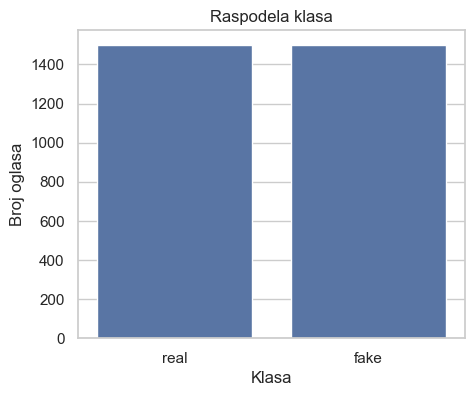

Duplicirani redovi: 0
Duplicirani full_text tekstovi: 0


In [24]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="label", order=["real", "fake"])
plt.title("Raspodela klasa")
plt.xlabel("Klasa")
plt.ylabel("Broj oglasa")
plt.show()

print("Duplicirani redovi:", df.duplicated().sum())
print("Duplicirani full_text tekstovi:", df["full_text"].duplicated().sum())


## 3. Kvalitet tekstualnih podataka

U ovom delu merimo osobine koje se u instrukcijama eksplicitno pominju za tekstualne podatke: duzina dokumenata, velicina recnika, leksicka raznovrsnost i prisustvo suma kao sto su HTML fragmenti, brojevi, interpunkcija, email/URL tokeni i tipografske varijacije.


In [25]:
WORD_RE = re.compile(r"\b[a-zA-Z][a-zA-Z0-9@_\-']*\b")
SENTENCE_RE = re.compile(r"[.!?]+")
HTML_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
EMAIL_RE = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b")
TYPO_RE = re.compile(r"[a-zA-Z][0@1][a-zA-Z]|[a-zA-Z]+[-@][a-zA-Z]+")


def word_tokens(text: str) -> list[str]:
    return WORD_RE.findall(str(text).lower())


def sentence_tokens(text: str) -> list[str]:
    pieces = SENTENCE_RE.split(str(text))
    return [piece.strip() for piece in pieces if piece.strip()]


def lexical_diversity(tokens: list[str]) -> float:
    return len(set(tokens)) / len(tokens) if tokens else 0.0


def uppercase_ratio(text: str) -> float:
    chars = [ch for ch in str(text) if ch.isalpha()]
    return sum(ch.isupper() for ch in chars) / len(chars) if chars else 0.0


def punctuation_ratio(text: str) -> float:
    text = str(text)
    return sum(ch in string.punctuation for ch in text) / len(text) if text else 0.0


def non_ascii_ratio(text: str) -> float:
    text = str(text)
    return sum(ord(ch) > 127 for ch in text) / len(text) if text else 0.0


df["word_tokens"] = df["full_text"].apply(word_tokens)
df["char_length"] = df["full_text"].str.len()
df["word_count"] = df["word_tokens"].apply(len)
df["sentence_count"] = df["full_text"].apply(lambda text: len(sentence_tokens(text)))
df["avg_word_length"] = df["word_tokens"].apply(lambda tokens: np.mean([len(t) for t in tokens]) if tokens else 0)
df["lexical_diversity"] = df["word_tokens"].apply(lexical_diversity)
df["html_tag_count"] = df["full_text"].apply(lambda text: len(HTML_RE.findall(str(text))))
df["url_count"] = df["full_text"].apply(lambda text: len(URL_RE.findall(str(text))))
df["email_count"] = df["full_text"].apply(lambda text: len(EMAIL_RE.findall(str(text))))
df["digit_count"] = df["full_text"].apply(lambda text: sum(ch.isdigit() for ch in str(text)))
df["punctuation_ratio"] = df["full_text"].apply(punctuation_ratio)
df["uppercase_ratio"] = df["full_text"].apply(uppercase_ratio)
df["non_ascii_ratio"] = df["full_text"].apply(non_ascii_ratio)
df["typo_proxy_count"] = df["full_text"].apply(lambda text: len(TYPO_RE.findall(str(text))))

QUALITY_COLUMNS = [
    "char_length",
    "word_count",
    "sentence_count",
    "avg_word_length",
    "lexical_diversity",
    "html_tag_count",
    "url_count",
    "email_count",
    "digit_count",
    "punctuation_ratio",
    "uppercase_ratio",
    "non_ascii_ratio",
    "typo_proxy_count",
]

display(df.groupby("label")[QUALITY_COLUMNS].mean().round(3).T)


label,fake,real
char_length,1959.599,1577.150
word_count,270.377,216.057
sentence_count,17.741,14.587
avg_word_length,6.088,6.126
lexical_diversity,0.636,0.662
html_tag_count,0.245,0.172
url_count,0.000,0.000
email_count,0.000,0.000
digit_count,4.153,3.957
punctuation_ratio,0.025,0.027


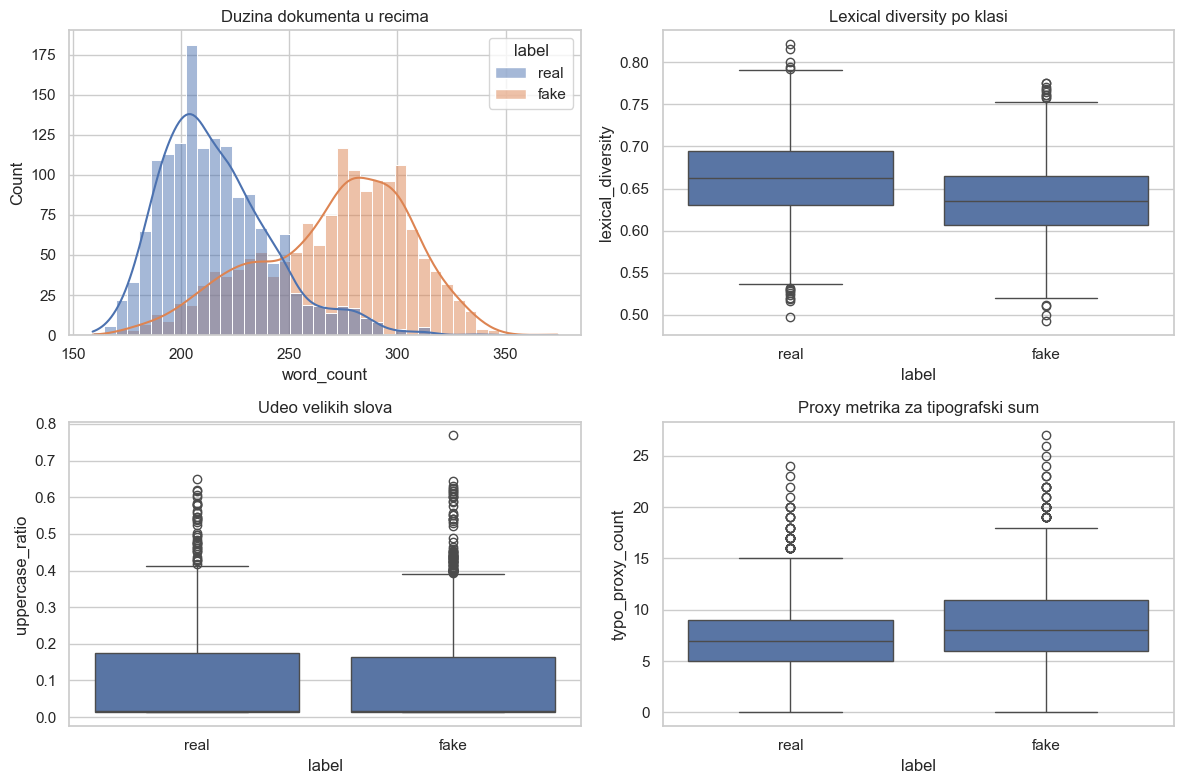

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(data=df, x="word_count", hue="label", bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Duzina dokumenta u recima")
sns.boxplot(data=df, x="label", y="lexical_diversity", order=["real", "fake"], ax=axes[0, 1])
axes[0, 1].set_title("Lexical diversity po klasi")
sns.boxplot(data=df, x="label", y="uppercase_ratio", order=["real", "fake"], ax=axes[1, 0])
axes[1, 0].set_title("Udeo velikih slova")
sns.boxplot(data=df, x="label", y="typo_proxy_count", order=["real", "fake"], ax=axes[1, 1])
axes[1, 1].set_title("Proxy metrika za tipografski sum")
plt.tight_layout()
plt.show()


In [27]:
def vocabulary_stats(frame: pd.DataFrame, text_col: str) -> pd.DataFrame:
    rows = []
    for label, part in frame.groupby("label"):
        tokens = [token for tokens in part[text_col].apply(word_tokens) for token in tokens]
        counter = Counter(tokens)
        rows.append(
            {
                "class": label,
                "total_tokens": len(tokens),
                "vocabulary_size": len(counter),
                "hapax_tokens": sum(1 for value in counter.values() if value == 1),
                "top_10_tokens": ", ".join(token for token, _ in counter.most_common(10)),
            }
        )
    return pd.DataFrame(rows)


display(vocabulary_stats(df, "full_text"))


,class,total_tokens,vocabulary_size,hapax_tokens,top_10_tokens
0,fake,405566,1174,307,"and, the, to, with, a, are, in, may, internal,..."
1,real,324086,1155,292,"and, with, to, the, a, in, are, role, internal..."


## 4. Tokenizacija: word, sentence i subword pogled

Klasicni BoW/TF-IDF modeli najcesce koriste reci kao tokene. Sentence tokenization je korisna za analizu strukture dokumenta. Subword pristup je vazan za savremene modele i za reci sa greskama; ovde ga demonstriramo karakter n-gramima, sto je lokalna i izvrsiva aproksimacija ideje iz FastText/BERT-like tokenizacije.


In [28]:
example_idx = 0
example_text = df.loc[example_idx, "full_text"]

def character_ngrams(text: str, n: int = 4, limit: int = 25) -> list[str]:
    compact = re.sub(r"\s+", " ", str(text).lower()).strip()
    grams = [compact[i : i + n] for i in range(max(0, len(compact) - n + 1))]
    return grams[:limit]


tokenization_preview = pd.DataFrame(
    {
        "word_tokens_first_25": [word_tokens(example_text)[:25]],
        "sentence_tokens_first_5": [sentence_tokens(example_text)[:5]],
        "char_4grams_first_25": [character_ngrams(example_text, n=4, limit=25)],
    }
).T

display(tokenization_preview)


,0
word_tokens_first_25,"[data, analyst, successful, candidates, commun..."
sentence_tokens_first_5,[Data Analyst Successful candidates communicat...
char_4grams_first_25,"[data, ata , ta a, a an, ana, anal, naly, aly..."


## 5. Predobrada teksta

Formiramo vise verzija istog teksta:

- `raw_text`: originalni spojeni tekst
- `normalized_text`: HTML ciscenje, Unicode normalizacija, lowercase, uklanjanje URL/email/brojeva/interpunkcije
- `no_stopwords_text`: normalizovan tekst bez engleskih stop-reci
- `stemmed_text`: Porter stemming nad tekstom bez stop-reci
- `lemmatized_text`: lagana rule-based lematizacija kao lokalna alternativa kada nema jezickih modela


In [29]:
stemmer = PorterStemmer()


def strip_html(text: str) -> str:
    return BeautifulSoup(str(text), "html.parser").get_text(" ")


def normalize_text(text: str) -> str:
    text = strip_html(text)
    text = unicodedata.normalize("NFKC", str(text))
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = EMAIL_RE.sub(" ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text


def remove_stopwords(text: str) -> str:
    return " ".join(token for token in str(text).split() if token not in ENGLISH_STOP_WORDS)


def stem_text(text: str) -> str:
    return " ".join(stemmer.stem(token) for token in str(text).split())


def simple_lemmatize_token(token: str) -> str:
    if len(token) > 5 and token.endswith("ies"):
        return token[:-3] + "y"
    if len(token) > 5 and token.endswith("ing"):
        return token[:-3]
    if len(token) > 4 and token.endswith("ed"):
        return token[:-2]
    if len(token) > 4 and token.endswith("s"):
        return token[:-1]
    return token


def lemmatize_text(text: str) -> str:
    return " ".join(simple_lemmatize_token(token) for token in str(text).split())


df["raw_text"] = df["full_text"]
df["normalized_text"] = df["raw_text"].apply(normalize_text)
df["no_stopwords_text"] = df["normalized_text"].apply(remove_stopwords)
df["stemmed_text"] = df["no_stopwords_text"].apply(stem_text)
df["lemmatized_text"] = df["no_stopwords_text"].apply(lemmatize_text)

preview = pd.DataFrame(
    {
        "raw_text": [df.loc[0, "raw_text"][:260]],
        "normalized_text": [df.loc[0, "normalized_text"][:260]],
        "no_stopwords_text": [df.loc[0, "no_stopwords_text"][:260]],
        "stemmed_text": [df.loc[0, "stemmed_text"][:260]],
        "lemmatized_text": [df.loc[0, "lemmatized_text"][:260]],
    }
).T

display(preview)


,0
raw_text,Data Analyst Successful candidates communicate...
normalized_text,data analyst successful candidates communicate...
no_stopwords_text,data analyst successful candidates communicate...
stemmed_text,data analyst success candid commun clearli sta...
lemmatized_text,data analyst successful candidate communicate ...


In [30]:
preprocessing_stats = []
for column in ["raw_text", "normalized_text", "no_stopwords_text", "stemmed_text", "lemmatized_text"]:
    tokens = [token for text in df[column] for token in str(text).split()]
    preprocessing_stats.append(
        {
            "text_variant": column,
            "total_tokens": len(tokens),
            "vocabulary_size": len(set(tokens)),
            "avg_tokens_per_doc": round(np.mean([len(str(text).split()) for text in df[column]]), 2),
        }
    )

display(pd.DataFrame(preprocessing_stats))


,text_variant,total_tokens,vocabulary_size,avg_tokens_per_doc
0,raw_text,747050,2659,249.02
1,normalized_text,733301,483,244.43
2,no_stopwords_text,487747,412,162.58
3,stemmed_text,487747,347,162.58
4,lemmatized_text,487747,381,162.58


## 6. Data augmentation

Augmentation se primenjuje samo nad trening podacima u jednom eksperimentu. Koristimo jednostavne i kontrolisane transformacije: zamenu nekoliko domenskih reci sinonimima i blago nasumicno izbacivanje tokena. Cilj nije da se napravi savrsen generator teksta, vec da se demonstrira kako augmentation moze povecati varijabilnost trening skupa.


In [31]:
SYNONYMS = {
    "job": ["position", "role"],
    "role": ["position", "job"],
    "team": ["group", "staff"],
    "candidate": ["applicant"],
    "candidates": ["applicants"],
    "company": ["organization"],
    "work": ["tasks"],
    "remote": ["online"],
    "support": ["assist"],
    "communication": ["collaboration"],
    "skills": ["abilities"],
    "experience": ["background"],
}


def augment_text(text: str, rng: random.Random, replacement_prob: float = 0.12, deletion_prob: float = 0.03) -> str:
    augmented = []
    for token in str(text).split():
        if rng.random() < deletion_prob and len(token) > 3:
            continue
        if token in SYNONYMS and rng.random() < replacement_prob:
            augmented.append(rng.choice(SYNONYMS[token]))
        else:
            augmented.append(token)
    return " ".join(augmented)


example_augmented = augment_text(df.loc[0, "normalized_text"], random.Random(RANDOM_STATE))
display(pd.DataFrame({"original": [df.loc[0, "normalized_text"][:260]], "augmented": [example_augmented[:260]]}).T)


,0
original,data analyst successful candidates communicate...
augmented,data successful candidates communicate clearly...


## 7. Modeli, reprezentacije i evaluacija

Poredimo reprezentacije koje se tipicno navode u teoriji:

- Bag of Words preko `CountVectorizer`
- TF-IDF preko `TfidfVectorizer`
- subword pristup preko karakter n-gram TF-IDF reprezentacije
- dense embedding baseline preko TF-IDF + LSA (`TruncatedSVD`)
- TF-IDF dopunjen metrikama kvaliteta teksta

Transformer modeli nisu instalirani u lokalnom okruzenju, pa se ne treniraju direktno. Notebook ipak proverava dostupnost biblioteka i koristi subword/dense baseline kao lokalno izvrsive mostove ka toj diskusiji.


In [32]:
TRANSFORMERS_AVAILABLE = importlib.util.find_spec("transformers") is not None
SENTENCE_TRANSFORMERS_AVAILABLE = importlib.util.find_spec("sentence_transformers") is not None

print("transformers available:", TRANSFORMERS_AVAILABLE)
print("sentence_transformers available:", SENTENCE_TRANSFORMERS_AVAILABLE)


transformers available: False
sentence_transformers available: False


In [33]:
y = df[TARGET].astype(int)
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))
print("Test class distribution:")
display(y.loc[test_idx].value_counts().sort_index().rename(index={0: "real", 1: "fake"}).to_frame("count"))


Train size: 2400
Test size: 600
Test class distribution:


,count
is_fake,
real,300
fake,300


In [34]:
def build_vectorizer(kind: str):
    if kind == "bow":
        return CountVectorizer(max_features=8000, ngram_range=(1, 2), min_df=2)
    if kind == "tfidf_word":
        return TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=2, sublinear_tf=True, strip_accents="unicode")
    if kind == "tfidf_char":
        return TfidfVectorizer(max_features=12000, analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True)
    raise ValueError(f"Nepoznata reprezentacija: {kind}")


def build_estimator(model_name: str):
    if model_name == "LogisticRegression":
        return LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)
    if model_name == "MultinomialNB":
        return MultinomialNB()
    raise ValueError(f"Nepoznat model: {model_name}")


def augment_training_set(texts: pd.Series, labels: pd.Series) -> tuple[pd.Series, pd.Series]:
    rng = random.Random(RANDOM_STATE)
    augmented_texts = texts.apply(lambda text: augment_text(text, rng))
    return pd.concat([texts, augmented_texts], ignore_index=True), pd.concat([labels, labels], ignore_index=True)


def evaluate_config(config: dict) -> dict:
    text_col = config["text_col"]
    X_train = df.loc[train_idx, text_col].astype(str)
    X_test = df.loc[test_idx, text_col].astype(str)
    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    if config.get("augment", False):
        X_train, y_train = augment_training_set(X_train.reset_index(drop=True), y_train.reset_index(drop=True))

    if config.get("dense_lsa", False):
        estimator = Pipeline(
            [
                ("tfidf", build_vectorizer("tfidf_word")),
                ("svd", TruncatedSVD(n_components=120, random_state=RANDOM_STATE)),
                ("clf", build_estimator(config["model"])),
            ]
        )
        estimator.fit(X_train, y_train)
        y_pred = estimator.predict(X_test)
        fitted = estimator
    else:
        vectorizer = build_vectorizer(config["vectorizer"])
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec = vectorizer.transform(X_test)

        scaler = None
        if config.get("quality_features", False):
            scaler = StandardScaler()
            train_quality = scaler.fit_transform(df.loc[train_idx, QUALITY_COLUMNS])
            test_quality = scaler.transform(df.loc[test_idx, QUALITY_COLUMNS])
            if config.get("augment", False):
                train_quality = np.vstack([train_quality, train_quality])
            X_train_vec = hstack([X_train_vec, train_quality])
            X_test_vec = hstack([X_test_vec, test_quality])

        estimator = build_estimator(config["model"])
        estimator.fit(X_train_vec, y_train)
        y_pred = estimator.predict(X_test_vec)
        fitted = {"vectorizer": vectorizer, "model": estimator, "scaler": scaler}

    return {
        "experiment": config["name"],
        "text_variant": text_col,
        "representation": config.get("representation", config.get("vectorizer", "dense_lsa")),
        "model": config["model"],
        "augmented_train": config.get("augment", False),
        "quality_features": config.get("quality_features", False),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, target_names=["real", "fake"]),
        "y_pred": y_pred,
        "fitted": fitted,
    }


In [35]:
EXPERIMENTS = [
    {"name": "BoW raw + LogisticRegression", "text_col": "raw_text", "vectorizer": "bow", "representation": "Bag of Words", "model": "LogisticRegression"},
    {"name": "BoW raw + MultinomialNB", "text_col": "raw_text", "vectorizer": "bow", "representation": "Bag of Words", "model": "MultinomialNB"},
    {"name": "TF-IDF raw + LogisticRegression", "text_col": "raw_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF normalized + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF no stopwords + LogisticRegression", "text_col": "no_stopwords_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF stemmed + LogisticRegression", "text_col": "stemmed_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF lemmatized + LogisticRegression", "text_col": "lemmatized_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "LogisticRegression"},
    {"name": "TF-IDF stemmed + MultinomialNB", "text_col": "stemmed_text", "vectorizer": "tfidf_word", "representation": "TF-IDF word ngrams", "model": "MultinomialNB"},
    {"name": "Subword char ngrams + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_char", "representation": "Character n-gram TF-IDF", "model": "LogisticRegression"},
    {"name": "TF-IDF stemmed + quality features", "text_col": "stemmed_text", "vectorizer": "tfidf_word", "representation": "TF-IDF + quality metrics", "model": "LogisticRegression", "quality_features": True},
    {"name": "Dense LSA baseline + LogisticRegression", "text_col": "normalized_text", "representation": "Dense LSA baseline", "model": "LogisticRegression", "dense_lsa": True},
    {"name": "Augmented TF-IDF normalized + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_word", "representation": "TF-IDF with train augmentation", "model": "LogisticRegression", "augment": True},
]

results = [evaluate_config(config) for config in EXPERIMENTS]
results_df = pd.DataFrame(
    [{key: value for key, value in row.items() if key not in {"confusion_matrix", "classification_report", "y_pred", "fitted"}} for row in results]
).sort_values("f1", ascending=False)

display(results_df.reset_index(drop=True))


,experiment,text_variant,representation,model,augmented_train,quality_features,accuracy,precision,recall,f1
0,Subword char ngrams + LogisticRegression,normalized_text,Character n-gram TF-IDF,LogisticRegression,False,False,0.823333,0.854015,0.780000,0.815331
1,TF-IDF raw + LogisticRegression,raw_text,TF-IDF word ngrams,LogisticRegression,False,False,0.820000,0.842857,0.786667,0.813793
2,TF-IDF stemmed + LogisticRegression,stemmed_text,TF-IDF word ngrams,LogisticRegression,False,False,0.820000,0.842857,0.786667,0.813793
3,Dense LSA baseline + LogisticRegression,normalized_text,Dense LSA baseline,LogisticRegression,False,False,0.820000,0.842857,0.786667,0.813793
4,BoW raw + MultinomialNB,raw_text,Bag of Words,MultinomialNB,False,False,0.823333,0.864662,0.766667,0.812721
5,TF-IDF stemmed + MultinomialNB,stemmed_text,TF-IDF word ngrams,MultinomialNB,False,False,0.823333,0.864662,0.766667,0.812721
6,TF-IDF lemmatized + LogisticRegression,lemmatized_text,TF-IDF word ngrams,LogisticRegression,False,False,0.818333,0.839858,0.786667,0.812392
7,Augmented TF-IDF normalized + LogisticRegression,normalized_text,TF-IDF with train augmentation,LogisticRegression,True,False,0.813333,0.819728,0.803333,0.811448
8,TF-IDF normalized + LogisticRegression,normalized_text,TF-IDF word ngrams,LogisticRegression,False,False,0.816667,0.836879,0.786667,0.810997
9,TF-IDF no stopwords + LogisticRegression,no_stopwords_text,TF-IDF word ngrams,LogisticRegression,False,False,0.816667,0.836879,0.786667,0.810997


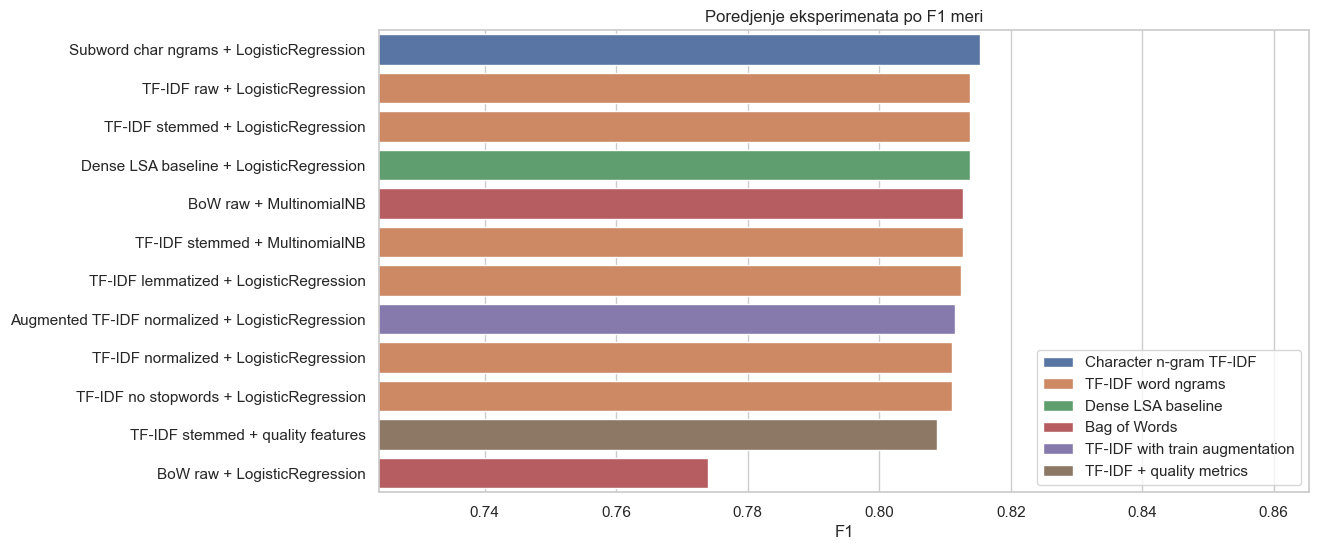

In [36]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="f1", y="experiment", hue="representation", dodge=False)
plt.title("Poredjenje eksperimenata po F1 meri")
plt.xlabel("F1")
plt.ylabel("")
plt.xlim(max(0, results_df["f1"].min() - 0.05), min(1, results_df["f1"].max() + 0.05))
plt.legend(loc="lower right")
plt.show()


## 8. Cross-validation za stabilniju procenu

Jedan train/test split je koristan za analizu gresaka, ali nije dovoljan za stabilan zakljucak. Zato za glavne konfiguracije radimo stratifikovanu 5-fold cross-validation evaluaciju.


In [37]:
CV_EXPERIMENTS = [
    {"name": "BoW raw + LogisticRegression", "text_col": "raw_text", "vectorizer": "bow", "model": "LogisticRegression"},
    {"name": "TF-IDF raw + LogisticRegression", "text_col": "raw_text", "vectorizer": "tfidf_word", "model": "LogisticRegression"},
    {"name": "TF-IDF normalized + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_word", "model": "LogisticRegression"},
    {"name": "TF-IDF no stopwords + LogisticRegression", "text_col": "no_stopwords_text", "vectorizer": "tfidf_word", "model": "LogisticRegression"},
    {"name": "TF-IDF stemmed + LogisticRegression", "text_col": "stemmed_text", "vectorizer": "tfidf_word", "model": "LogisticRegression"},
    {"name": "TF-IDF lemmatized + LogisticRegression", "text_col": "lemmatized_text", "vectorizer": "tfidf_word", "model": "LogisticRegression"},
    {"name": "Subword char ngrams + LogisticRegression", "text_col": "normalized_text", "vectorizer": "tfidf_char", "model": "LogisticRegression"},
    {"name": "Dense LSA baseline + LogisticRegression", "text_col": "normalized_text", "model": "LogisticRegression", "dense_lsa": True},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1"}

cv_rows = []
for config in CV_EXPERIMENTS:
    if config.get("dense_lsa", False):
        estimator = Pipeline(
            [
                ("tfidf", build_vectorizer("tfidf_word")),
                ("svd", TruncatedSVD(n_components=120, random_state=RANDOM_STATE)),
                ("clf", build_estimator(config["model"])),
            ]
        )
    else:
        estimator = Pipeline(
            [
                ("vectorizer", build_vectorizer(config["vectorizer"])),
                ("clf", build_estimator(config["model"])),
            ]
        )

    scores = cross_validate(estimator, df[config["text_col"]], y, cv=cv, scoring=scoring)
    cv_rows.append(
        {
            "experiment": config["name"],
            "accuracy_mean": scores["test_accuracy"].mean(),
            "accuracy_std": scores["test_accuracy"].std(),
            "precision_mean": scores["test_precision"].mean(),
            "recall_mean": scores["test_recall"].mean(),
            "f1_mean": scores["test_f1"].mean(),
            "f1_std": scores["test_f1"].std(),
        }
    )

cv_results_df = pd.DataFrame(cv_rows).sort_values("f1_mean", ascending=False)
display(cv_results_df.round(4).reset_index(drop=True))


,experiment,accuracy_mean,accuracy_std,precision_mean,recall_mean,f1_mean,f1_std
0,TF-IDF normalized + LogisticRegression,0.8343,0.0128,0.8979,0.7547,0.8198,0.0162
1,TF-IDF lemmatized + LogisticRegression,0.8340,0.0126,0.8991,0.7527,0.8191,0.0157
2,TF-IDF stemmed + LogisticRegression,0.8337,0.0127,0.8990,0.7520,0.8187,0.0157
3,TF-IDF raw + LogisticRegression,0.8333,0.0128,0.8971,0.7533,0.8186,0.0162
4,TF-IDF no stopwords + LogisticRegression,0.8333,0.0130,0.8990,0.7513,0.8182,0.0163
5,Dense LSA baseline + LogisticRegression,0.8327,0.0116,0.9001,0.7487,0.8172,0.0144
6,Subword char ngrams + LogisticRegression,0.8317,0.0110,0.9005,0.7460,0.8157,0.0140
7,BoW raw + LogisticRegression,0.7863,0.0175,0.7919,0.7767,0.7841,0.0191


## 9. Najbolji model, konfuziona matrica i analiza gresaka

Za najbolji train/test eksperiment prikazujemo konfuzionu matricu i konkretne primere gresaka. Ovo je vazno jer u detekciji prevara precision i recall nemaju istu prakticnu cenu.


Najbolji eksperiment: Subword char ngrams + LogisticRegression
Accuracy: 0.8233
Precision: 0.854
Recall: 0.78
F1: 0.8153

              precision    recall  f1-score   support

        real       0.80      0.87      0.83       300
        fake       0.85      0.78      0.82       300

    accuracy                           0.82       600
   macro avg       0.83      0.82      0.82       600
weighted avg       0.83      0.82      0.82       600



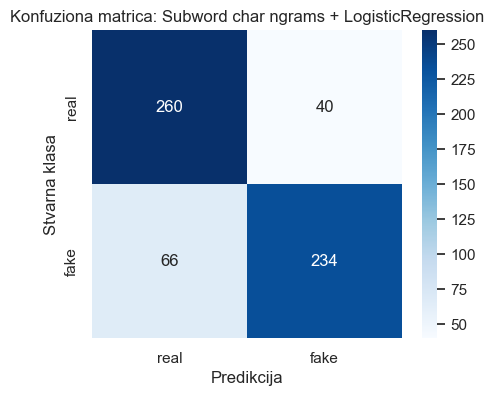

In [38]:
best_result = max(results, key=lambda row: row["f1"])

print("Najbolji eksperiment:", best_result["experiment"])
print("Accuracy:", round(best_result["accuracy"], 4))
print("Precision:", round(best_result["precision"], 4))
print("Recall:", round(best_result["recall"], 4))
print("F1:", round(best_result["f1"], 4))
print()
print(best_result["classification_report"])

plt.figure(figsize=(5, 4))
sns.heatmap(best_result["confusion_matrix"], annot=True, fmt="d", cmap="Blues", xticklabels=["real", "fake"], yticklabels=["real", "fake"])
plt.title(f"Konfuziona matrica: {best_result['experiment']}")
plt.xlabel("Predikcija")
plt.ylabel("Stvarna klasa")
plt.show()


In [39]:
error_df = df.loc[test_idx, ["job_title", "label", "full_text", "word_count", "lexical_diversity", "typo_proxy_count"]].copy()
error_df["predicted_label"] = pd.Series(best_result["y_pred"], index=test_idx).map({0: "real", 1: "fake"})
error_df["error_type"] = np.where(
    (error_df["label"] == "real") & (error_df["predicted_label"] == "fake"),
    "false_positive",
    np.where(
        (error_df["label"] == "fake") & (error_df["predicted_label"] == "real"),
        "false_negative",
        "correct",
    ),
)

errors = error_df[error_df["error_type"] != "correct"].copy()
errors["snippet"] = errors["full_text"].str.replace("\n", " ", regex=False).str.slice(0, 320)

print("Broj gresaka po tipu:")
display(errors["error_type"].value_counts().to_frame("count"))
display(errors[["error_type", "job_title", "label", "predicted_label", "word_count", "lexical_diversity", "typo_proxy_count", "snippet"]].head(8))


Broj gresaka po tipu:


,count
error_type,
false_negative,66
false_positive,40


,error_type,job_title,label,predicted_label,word_count,lexical_diversity,typo_proxy_count,snippet
2044,false_negative,Financial Reporting Analyst,fake,real,225,0.648889,14,Financial Reporting Analyst The r0le supports ...
2976,false_negative,Software Engineer,fake,real,246,0.638211,5,Software Engineer The position includes a mix ...
2737,false_negative,Sales Operations Associate,fake,real,236,0.665254,6,Sales Operations Associate The role supports a...
2601,false_positive,HR Generalist,real,fake,250,0.644000,7,HR Generalist We are looking for someone who c...
2777,false_negative,Data Analyst,fake,real,195,0.682051,5,Data Analyst The position includes a mix of ro...
2331,false_negative,Operations Coordinator,fake,real,273,0.604396,5,Operations Coordinator The role supports a sma...
2778,false_positive,Software Engineer,real,fake,310,0.638710,13,Software Engineer The position includes a mix ...
1040,false_negative,Product Designer,fake,real,220,0.636364,6,Product Designer Our team works in short plann...


In [40]:
interpret_config = next(config for config in EXPERIMENTS if config["name"] == "TF-IDF stemmed + LogisticRegression")
interpret_result = evaluate_config(interpret_config)
vectorizer = interpret_result["fitted"]["vectorizer"]
model = interpret_result["fitted"]["model"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = model.coef_[0]
top_fake = pd.DataFrame({"token_or_ngram": feature_names[np.argsort(coefs)[-20:][::-1]], "coefficient": np.sort(coefs)[-20:][::-1]})
top_real = pd.DataFrame({"token_or_ngram": feature_names[np.argsort(coefs)[:20]], "coefficient": np.sort(coefs)[:20]})

print("Najjacih 20 indikatora za fake klasu u interpretabilnom TF-IDF modelu:")
display(top_fake)
print("Najjacih 20 indikatora za real klasu u interpretabilnom TF-IDF modelu:")
display(top_real)


Najjacih 20 indikatora za fake klasu u interpretabilnom TF-IDF modelu:


,token_or_ngram,coefficient
0,channel,1.435690
1,assign,1.257821
2,account,1.212444
3,materi updat,1.210074
4,publicfac,1.210074
5,publicfac materi,1.210074
6,work publicfac,1.210074
7,support confidenti,1.210074
8,client work,1.199356
9,contact,1.168739


Najjacih 20 indikatora za real klasu u interpretabilnom TF-IDF modelu:


,token_or_ngram,coefficient
0,ad team,-1.005879
1,locat paid,-0.916987
2,practic partner,-0.916781
3,region work,-0.788490
4,workflow flexibl,-0.717192
5,earli ref,-0.666266
6,ref bonu,-0.660570
7,checkin paid,-0.645292
8,path recruit,-0.643510
9,window health,-0.628354


## 10. Zakljucak

Ovaj notebook pokazuje da se kvalitet teksta ne meri samo nedostajucim vrednostima. Duzina dokumenta, recnik, lexical diversity i razliciti oblici suma menjaju prostor osobina koji model vidi.

U poredjenju modela najvaznije je tumaciti ne samo najbolju F1 meru, vec i stabilnost kroz cross-validation, odnos precision/recall i tipove gresaka. Ako su razlike izmedju predobrada male, to je i dalje koristan rezultat: osnovni tekst je vec dovoljno uredjen ili su klase takve da zahtevaju bogatije semanticke modele.

Za dalje unapredjenje najkorisniji pravci su: realniji javni skup podataka, validacija na vise izvora, detaljnija analiza shortcut signala, pretrained embeddings ili transformer modeli ako postoje lokalni resursi, i rucna provera najtezih false positive/false negative primera.
